In [1]:
import pandas as pd  
import re
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from gensim.models import Word2Vec
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.manifold import TSNE
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

In [7]:
# Veri setini yükleme
df = pd.read_csv("/Users/poyrazgunal/Desktop/Proje3.csv")

# Veri ön işlemleri
print(df.head())
print("Veri seti boyutu:", df.shape)
print("Eksik değerler:", df.isnull().sum())

df.dropna(inplace=True)  # Eksik verileri kaldır

# 📌 Stopwords listesini yükleme (Eksik satır eklendi)

stop_words = set(stopwords.words("english"))  # İngilizce durak kelimeleri

# 📌 Stopwords güncelleme
extra_stopwords = {"movie", "film", "br", "one", "character", "story", "time", "see", "like", "get", "make", "-", "would"}
stop_words.update(extra_stopwords)

# Temizlik fonksiyonu
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["clean_review"] = df["review"].apply(clean_text)

df["word_count"] = df["clean_review"].apply(lambda x: len(x.split()))


                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Veri seti boyutu: (50000, 2)
Eksik değerler: review       0
sentiment    0
dtype: int64


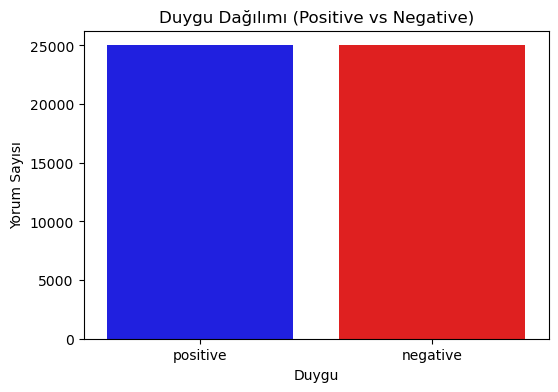

In [9]:
# Sınıf dağılımını görselleştir
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sentiment", hue="sentiment", legend=False, palette={"positive": "blue", "negative": "red"})
plt.title("Duygu Dağılımı (Positive vs Negative)")
plt.xlabel("Duygu")
plt.ylabel("Yorum Sayısı")
plt.show()

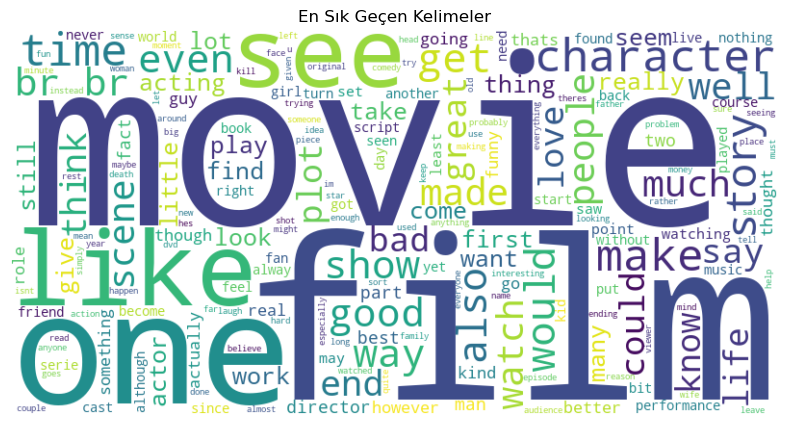

In [11]:
# İngilizce durdurma kelimelerini yükleme
stop_words = set(stopwords.words("english"))

# Tüm yorumları birleştirme
text = " ".join(df["review"]).lower()

# Noktalama işaretlerini temizleme
text = text.translate(str.maketrans("", "", string.punctuation))

# Kelime bulutu oluşturma
wordcloud = WordCloud(width=800, height=400, stopwords=stop_words, background_color="white").generate(text)

# Kelime bulutunu görselleştirme
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("En Sık Geçen Kelimeler")
plt.show()

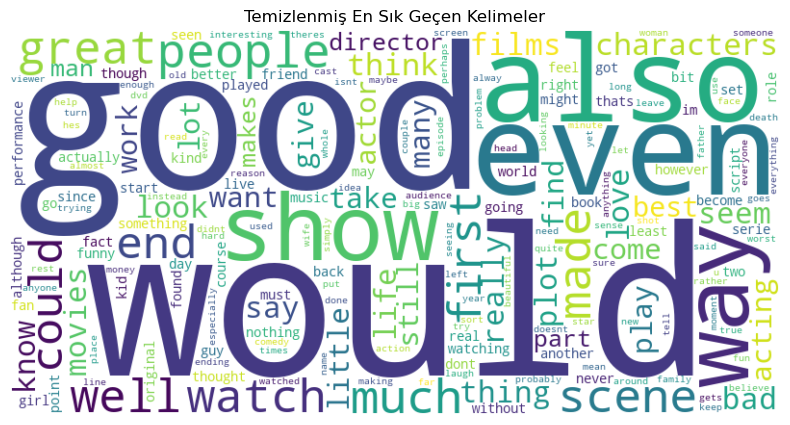

In [13]:
# Gereksiz kelimeleri ekleyelim
extra_stopwords = {"movie", "film", "br", "one", "character", "story", "time", "see", "like", "get", "make"}
stop_words.update(extra_stopwords)

# Temizlenmiş kelime bulutu oluşturalım 
wordcloud_clean = WordCloud(width=800, height=400, stopwords=stop_words, background_color="white").generate(text)

# Yeni WordCloud görselleştirme
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_clean, interpolation="bilinear")
plt.axis("off")
plt.title("Temizlenmiş En Sık Geçen Kelimeler")
plt.show()

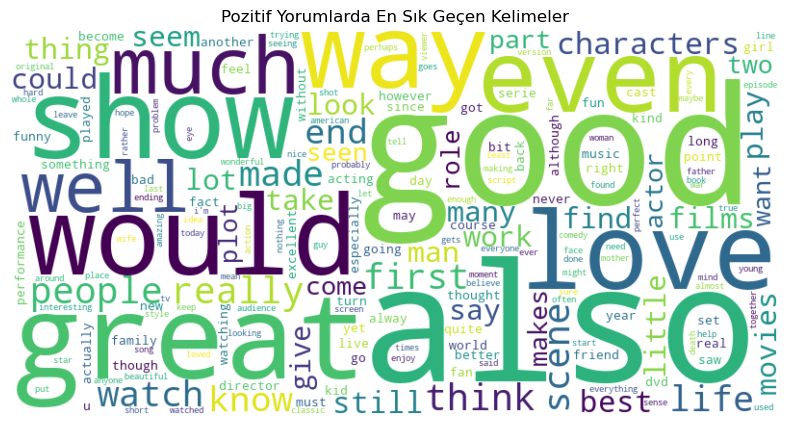

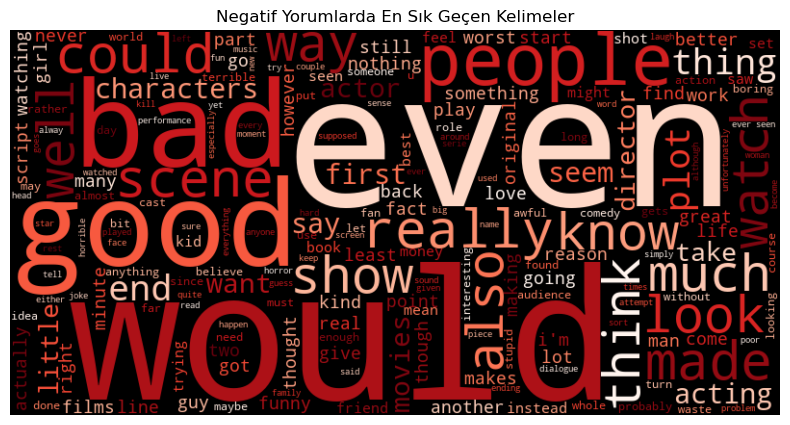

In [15]:
# Pozitif ve negatif yorumları ayıralım
positive_text = " ".join(df[df["sentiment"] == "positive"]["review"]).lower()
negative_text = " ".join(df[df["sentiment"] == "negative"]["review"]).lower()

# Pozitif yorumlar için WordCloud
wordcloud_pos = WordCloud(width=800, height=400, stopwords=stop_words, background_color="white").generate(positive_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Pozitif Yorumlarda En Sık Geçen Kelimeler")
plt.show()

# Negatif yorumlar için WordCloud
wordcloud_neg = WordCloud(width=800, height=400, stopwords=stop_words, background_color="black", colormap="Reds").generate(negative_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Negatif Yorumlarda En Sık Geçen Kelimeler")
plt.show()

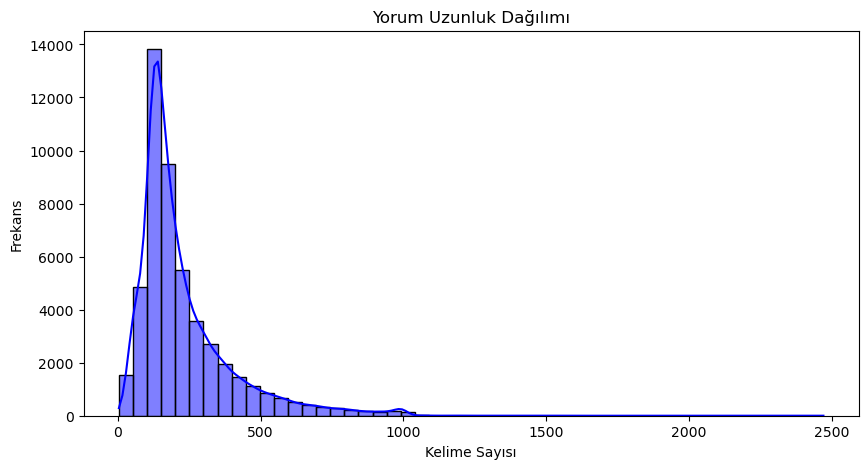

In [17]:
# Yorumlardaki kelime sayısını hesaplama
df["word_count"] = df["review"].apply(lambda x: len(x.split()))

# Histogram 
plt.figure(figsize=(10,5))
sns.histplot(df["word_count"], bins=50, kde=True, color="blue")
plt.xlabel("Kelime Sayısı")
plt.ylabel("Frekans")
plt.title("Yorum Uzunluk Dağılımı")
plt.show()

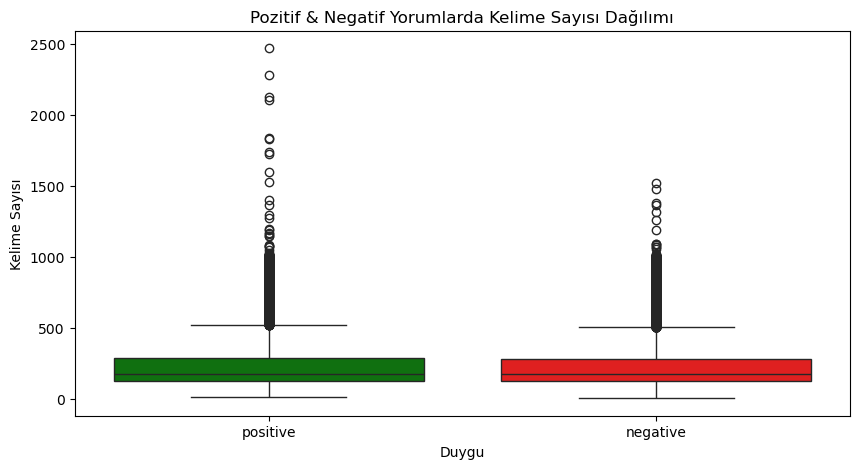

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="sentiment", y="word_count", hue="sentiment", legend=False, palette={"positive": "green", "negative": "red"})
plt.xlabel("Duygu")
plt.ylabel("Kelime Sayısı")
plt.title("Pozitif & Negatif Yorumlarda Kelime Sayısı Dağılımı")
plt.show()

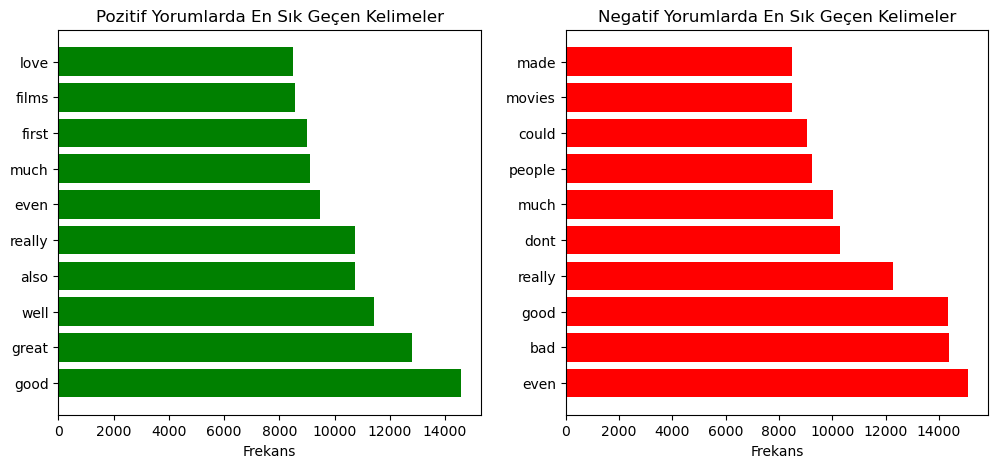

In [21]:
# Ekstra gereksiz kelimeleri listeye ekleyelim
extra_stopwords = {"movie", "film", "br", "one", "character", "story", "time", "see", "like", "get", "make", "-", "would"}
stop_words.update(extra_stopwords)

# Fonksiyon: Temizlik işlemi
def clean_text(text):
    text = text.lower()  # Küçük harfe çevir
    text = re.sub(r"<br\s*/?>", " ", text)  # <br> etiketlerini kaldır
    text = re.sub(r"[^a-z\s]", "", text)  # Harf olmayan her şeyi kaldır
    return text

# Yorumları temizle
df["clean_review"] = df["review"].apply(clean_text)

# Pozitif ve negatif yorumları ayıralım
positive_words = [word for word in " ".join(df[df["sentiment"] == "positive"]["clean_review"]).split() if word not in stop_words]
negative_words = [word for word in " ".join(df[df["sentiment"] == "negative"]["clean_review"]).split() if word not in stop_words]

# En sık geçen kelimeleri say
pos_counts = Counter(positive_words)
neg_counts = Counter(negative_words)

# En sık geçen ilk 10 kelimeyi seçelim
pos_common = dict(pos_counts.most_common(10))
neg_common = dict(neg_counts.most_common(10))

# görselleştirme
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.barh(list(pos_common.keys()), list(pos_common.values()), color="green")
plt.xlabel("Frekans")
plt.title("Pozitif Yorumlarda En Sık Geçen Kelimeler")

plt.subplot(1,2,2)
plt.barh(list(neg_common.keys()), list(neg_common.values()), color="red")
plt.xlabel("Frekans")
plt.title("Negatif Yorumlarda En Sık Geçen Kelimeler")

plt.show()

In [23]:
# TF-IDF vektörleme
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X = vectorizer.fit_transform(df["clean_review"])
y = df["sentiment"].map({"negative": 0, "positive": 1})


In [25]:
# Veriyi eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [27]:
# Makine Öğrenmesi Modelleri
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)
y_pred_nb = model_nb.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

logreg = LogisticRegression(max_iter=500)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)


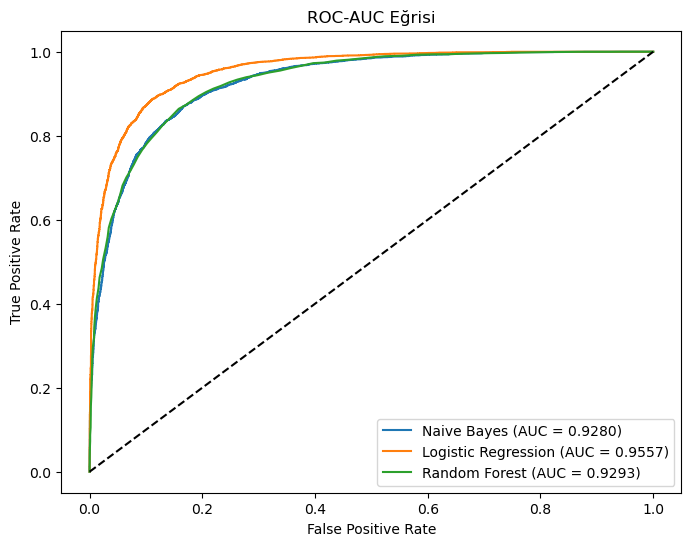

In [29]:
# ROC AUC Eğrisi
plt.figure(figsize=(8,6))
fpr_nb, tpr_nb, _ = roc_curve(y_test, model_nb.predict_proba(X_test)[:,1])
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc(fpr_nb, tpr_nb):.4f})")

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, logreg.predict_proba(X_test)[:,1])
plt.plot(fpr_logreg, tpr_logreg, label=f"Logistic Regression (AUC = {auc(fpr_logreg, tpr_logreg):.4f})")

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc(fpr_rf, tpr_rf):.4f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Eğrisi")
plt.legend()
plt.show()

In [31]:
# LSTM Modeli
MAX_NB_WORDS = 5000
MAX_SEQUENCE_LENGTH = 200
tokenizer = Tokenizer(num_words=MAX_NB_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_review"])
X_seq = tokenizer.texts_to_sequences(df["clean_review"])
X_seq = pad_sequences(X_seq, maxlen=MAX_SEQUENCE_LENGTH)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X_seq, y, test_size=0.2, random_state=42)

model_lstm = Sequential([
    Embedding(MAX_NB_WORDS, 128, input_length=MAX_SEQUENCE_LENGTH),
    Bidirectional(LSTM(64, return_sequences=True)),
    LSTM(32),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model_lstm.fit(X_train_seq, y_train_seq, epochs=10, batch_size=64, validation_data=(X_test_seq, y_test_seq), verbose=1)

loss, accuracy_lstm = model_lstm.evaluate(X_test_seq, y_test_seq)
print(f"LSTM Modeli Doğruluk: {accuracy_lstm:.4f}")


Epoch 1/10


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 113s 178ms/step - accuracy: 0.7319 - loss: 0.5121 - val_accuracy: 0.8621 - val_loss: 0.3181
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 127s 204ms/step - accuracy: 0.8936 - loss: 0.2685 - val_accuracy: 0.8062 - val_loss: 0.4023
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 124s 198ms/step - accuracy: 0.9088 - loss: 0.2395 - val_accuracy: 0.8833 - val_loss: 0.2802
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 192ms/step - accuracy: 0.9348 - loss: 0.1765 - val_accuracy: 0.8836 - val_loss: 0.2906
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 127s 204ms/step - accuracy: 0.9471 - loss: 0.1452 - val_accuracy: 0.8826 - val_loss: 0.3529
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 119s 190ms/step - accuracy: 0.9580 - loss: 0.1163 - val_accuracy: 0.8756 - val_loss: 0.4342
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 134s 214ms/step - accuracy: 0.9670 - loss: 0.0920 - val_accuracy: 0.8765 - val_loss: 0.3940
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 238ms/step - accuracy: 0.9724 - loss: 0.08

/var/folders/wj/m0kb8jyj6xz2znhc6tgkb8y00000gn/T/ipykernel_1565/532068418.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette="viridis")


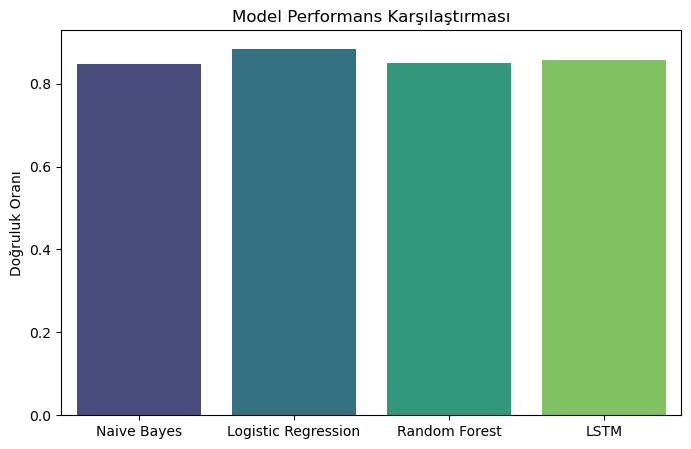

In [33]:
# Model Performans Karşılaştırması
models = ["Naive Bayes", "Logistic Regression", "Random Forest", "LSTM"]
accuracies = [accuracy_nb, accuracy_logreg, accuracy_rf, accuracy_lstm]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracies, palette="viridis")
plt.ylabel("Doğruluk Oranı")
plt.title("Model Performans Karşılaştırması")
plt.show()

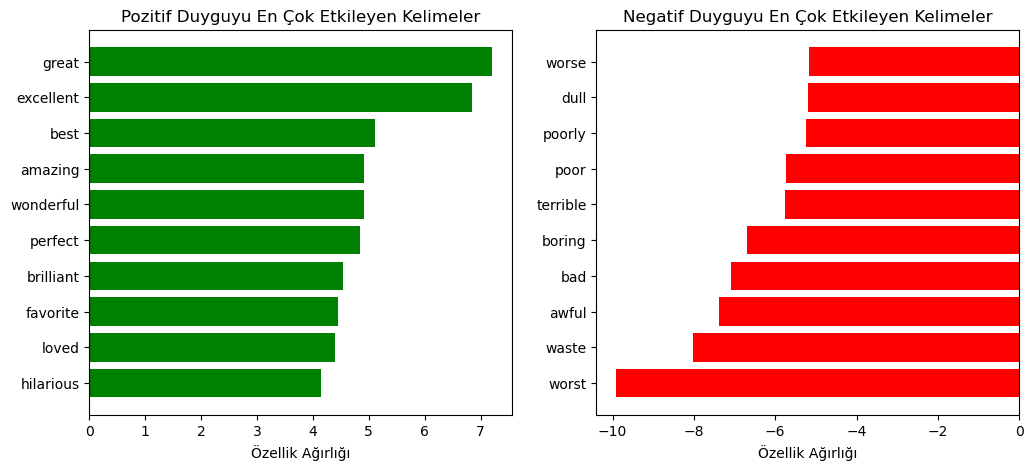

In [35]:
# Logistic Regression modelinden özellik alma 
feature_names = vectorizer.get_feature_names_out()
coef = logreg.coef_[0]

# En önemli pozitif ve negatif kelimeleri seçme
top_positive = np.argsort(coef)[-10:]  # En büyük 10 pozitif kelime
top_negative = np.argsort(coef)[:10]  # En küçük 10 negatif kelime

# Görsel
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.barh([feature_names[i] for i in top_positive], coef[top_positive], color="green")
plt.xlabel("Özellik Ağırlığı")
plt.title("Pozitif Duyguyu En Çok Etkileyen Kelimeler")

plt.subplot(1,2,2)
plt.barh([feature_names[i] for i in top_negative], coef[top_negative], color="red")
plt.xlabel("Özellik Ağırlığı")
plt.title("Negatif Duyguyu En Çok Etkileyen Kelimeler")

plt.show()

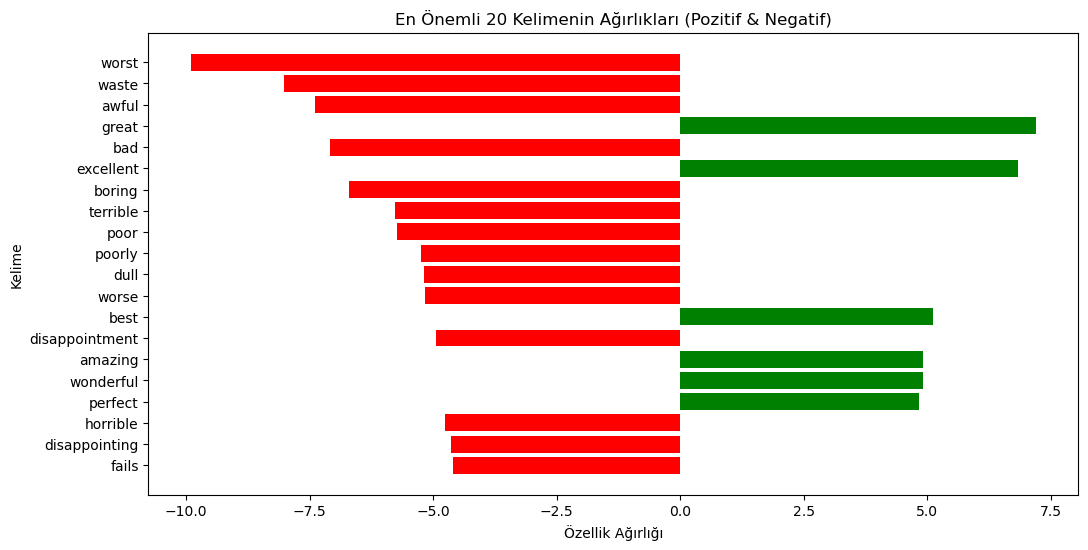

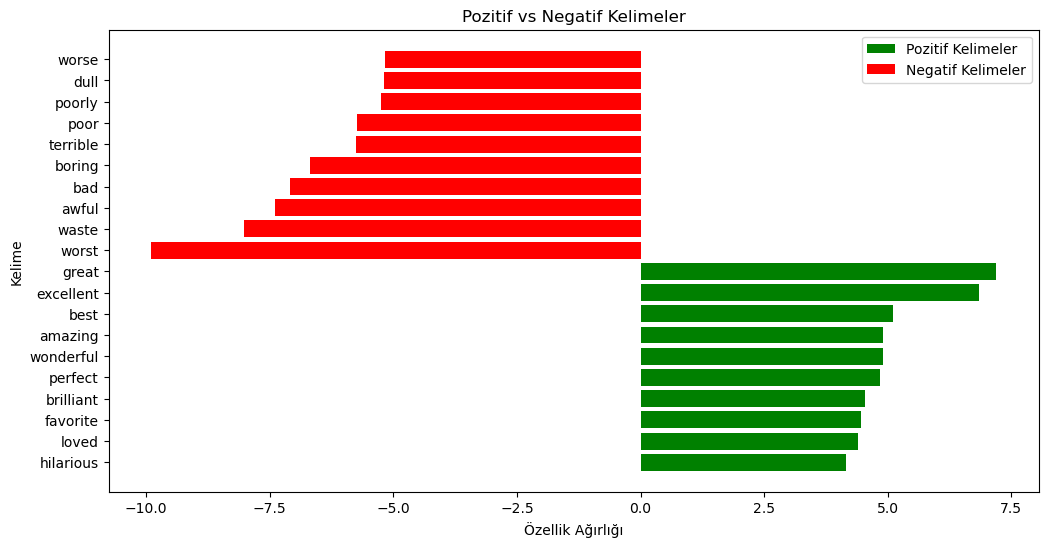

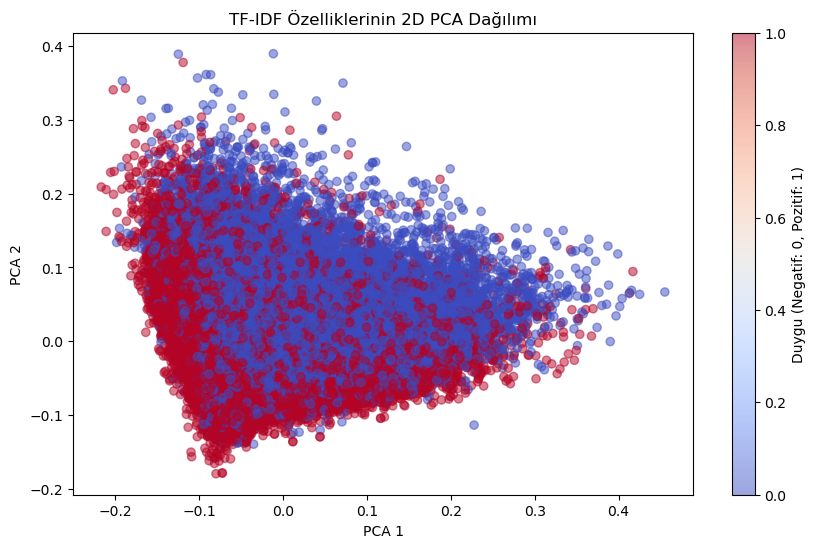

In [37]:
#Pozitif Negatif Kelimeler - Büyükten Küçüğe Barplot
plt.figure(figsize=(12, 6))
top_features = np.argsort(np.abs(coef))[-20:]  # En büyük 20 özelliği seç
plt.barh([feature_names[i] for i in top_features], coef[top_features], color=["red" if coef[i] < 0 else "green" for i in top_features])
plt.xlabel("Özellik Ağırlığı")
plt.ylabel("Kelime")
plt.title("En Önemli 20 Kelimenin Ağırlıkları (Pozitif & Negatif)")
plt.show()

# Pozitif Negatif Kelimeleri Yan Yana Karşılaştırmalı Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

ax.barh([feature_names[i] for i in top_positive], coef[top_positive], color="green", label="Pozitif Kelimeler")
ax.barh([feature_names[i] for i in top_negative], coef[top_negative], color="red", label="Negatif Kelimeler")
ax.set_xlabel("Özellik Ağırlığı")
ax.set_ylabel("Kelime")
ax.set_title("Pozitif vs Negatif Kelimeler")
ax.legend()
plt.show()

# TF-IDF Özelliklerini 2D Görselleştirme (PCA)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())  

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.5)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("TF-IDF Özelliklerinin 2D PCA Dağılımı")
plt.colorbar(label="Duygu (Negatif: 0, Pozitif: 1)")
plt.show()


In [43]:
#  LDA için BoW (Bag-of-Words) vektörleştirme
count_vectorizer = CountVectorizer(stop_words="english", max_features=5000)
X_counts = count_vectorizer.fit_transform(df["clean_review"])
optimal_topics = 6  
# LDA Modelini Eğitme
lda_model = LatentDirichletAllocation(n_components=6, random_state=42, n_jobs=-1)
lda_model.fit(X_counts)

LatentDirichletAllocation(n_components=6, n_jobs=-1, random_state=42)

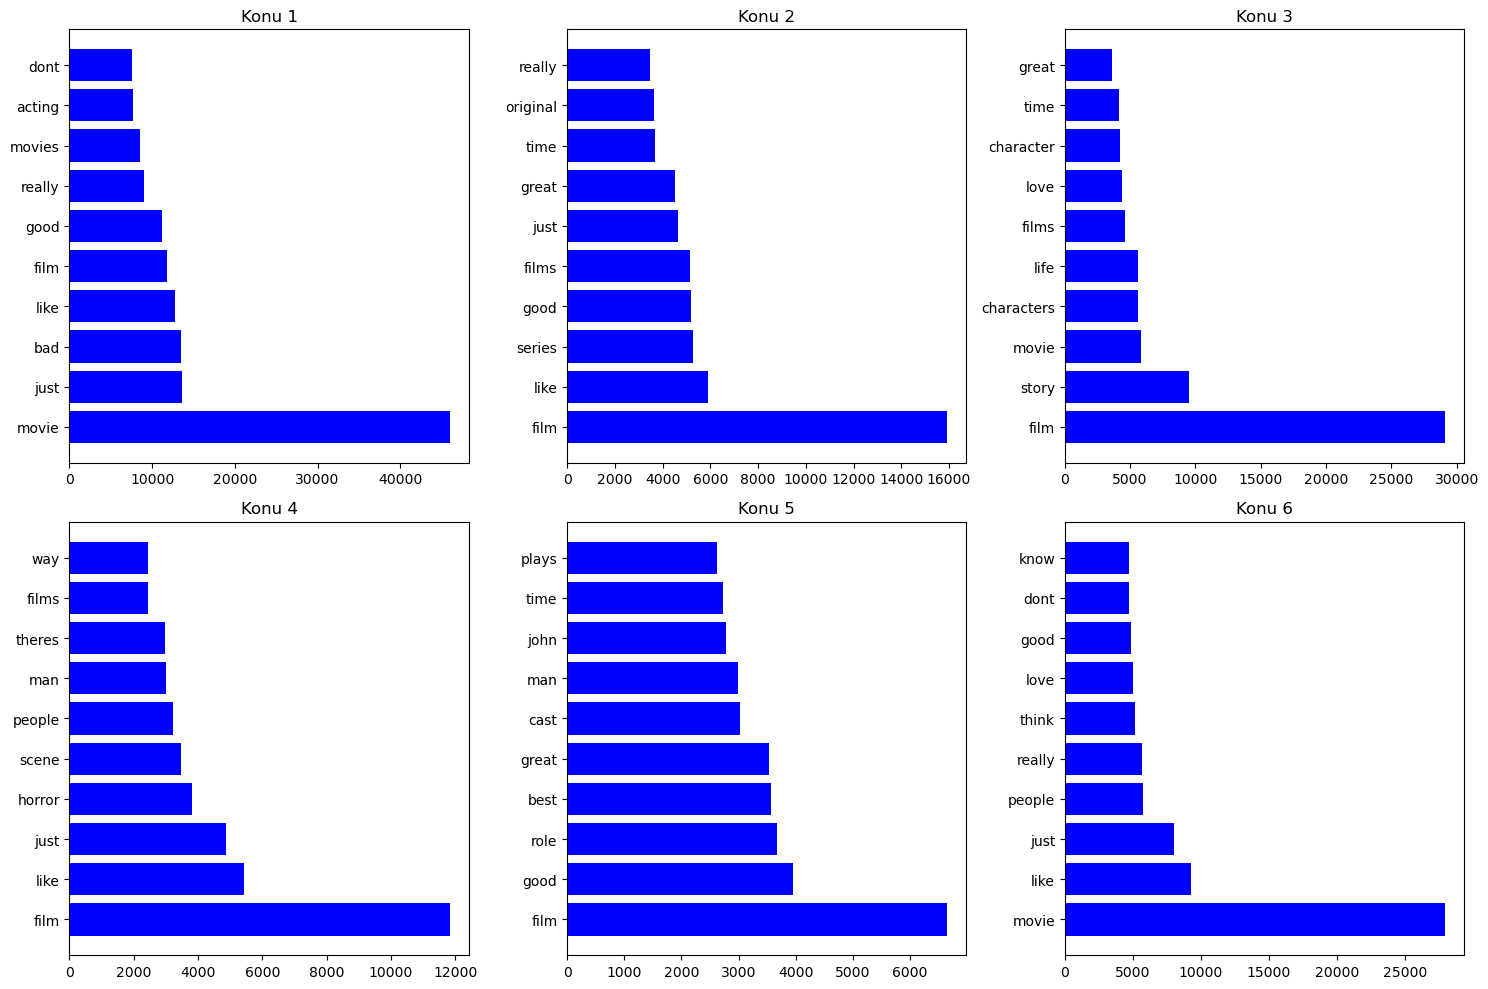

In [45]:
#  Konuların en önemli kelimelerini görselleştirme
num_words = 10  

fig, axes = plt.subplots(2, 3, figsize=(15, 10))  
axes = axes.flatten()

for topic_idx, topic in enumerate(lda_model.components_[:6]):  
    top_words = [count_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-num_words - 1:-1]]
    top_scores = topic[topic.argsort()[:-num_words - 1:-1]]

    ax = axes[topic_idx]
    ax.barh(top_words, top_scores, color="blue")
    ax.set_title(f"Konu {topic_idx + 1}")

plt.tight_layout()
plt.show()

In [47]:
#  Yorumları en güçlü oldukları konuya atama
topic_assignments = lda_model.transform(X_counts).argmax(axis=1)
df["assigned_topic"] = topic_assignments

# Konulara göre örnek yorumlar gösterelim
for topic_num in range(optimal_topics):
    print(f"\n Konu {topic_num}:")
    print(df[df["assigned_topic"] == topic_num]["clean_review"].sample(1).values[0])  # Rastgele bir yorum



📌 Konu 0:
i am almost tempted to demand my money back from the video store this movie plumbs the depths of inanity and is almost completely unwatchable i never bail out of a film early but this was painful to view a thorough waste of celluloid my vote  it would have been zero

📌 Konu 1:
talk about your classics ernie fossilus the foss from here on out came up with a cute and creative trailer totally spoofing star wars this gem is so jammed packed with tributes and gags i laugh every time not only that when star wars did a reissue with new special effects hardware wars did the same talk about a spoof that just wont die theres a reason george lucas calls this his favorite parody he was so impressed he even hired the foss to work on return of the jedi dont believe me check his entry in imdb  this has to be the first and in my opinion the best parody ever done i think the special edition was a bit overdone but on reflection i think its perfect for the modern day rerelease of star wars and

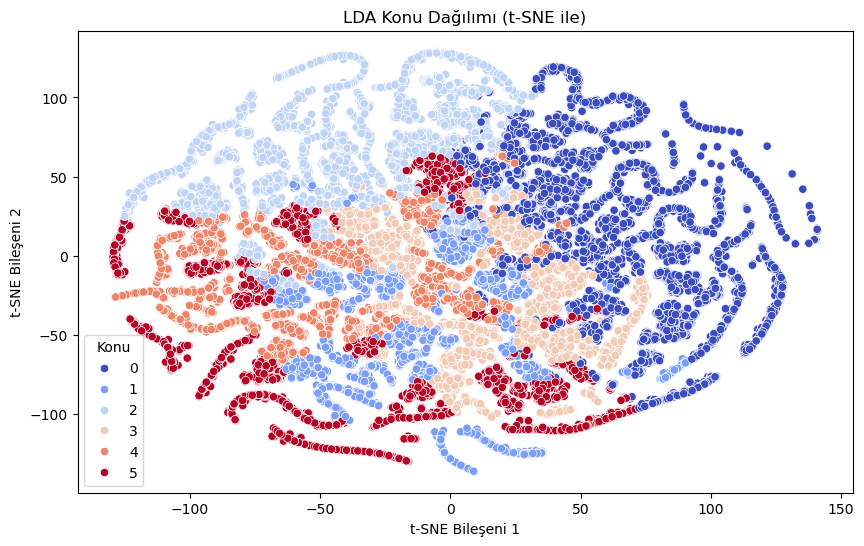

In [49]:
#  LDA ile elde edilen konu dağılımlarını 2D'ye indir
tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(lda_model.transform(X_counts))

#  Konuları renklendirerek görselle
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=df["assigned_topic"], palette="coolwarm")
plt.xlabel("t-SNE Bileşeni 1")
plt.ylabel("t-SNE Bileşeni 2")
plt.title("LDA Konu Dağılımı (t-SNE ile)")
plt.legend(title="Konu")
plt.show()


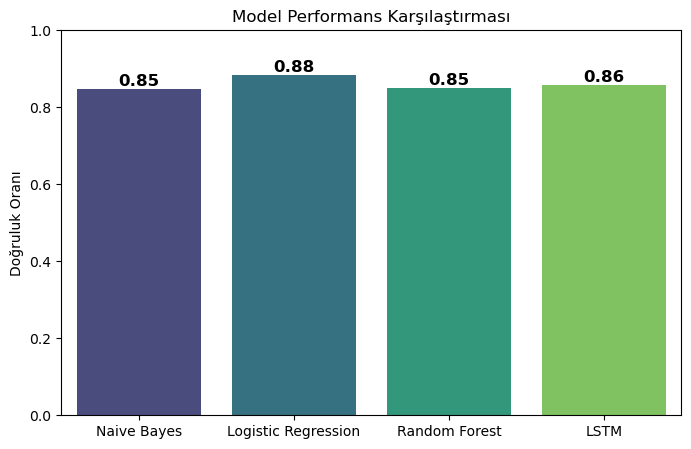

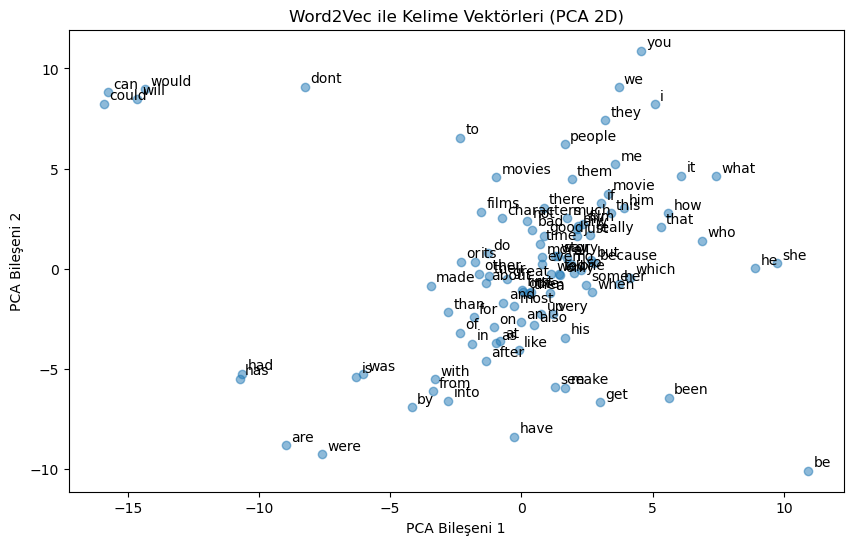

In [64]:
#  Doğru Modeli Seçme ve Görselleştirme
plt.figure(figsize=(8,5))
ax = sns.barplot(x=models, y=accuracies, hue=models, palette="viridis", legend=False)
plt.ylim(0, 1)  

# Doğruluk oranlarını sütunların üzerine yazdır
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, color='black', fontweight='bold')

plt.ylabel("Doğruluk Oranı")
plt.title("Model Performans Karşılaştırması")
plt.show()

# Kelimeleri Görselleştirme - Word2Vec + PCA
plt.figure(figsize=(10,6))
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], alpha=0.5)

# Kelime etiketlerini daha okunaklı hale getir
for i, word in enumerate(words):
    plt.annotate(word, (word_vectors_2d[i, 0] + 0.2, word_vectors_2d[i, 1] + 0.2), fontsize=10)

plt.xlabel("PCA Bileşeni 1")
plt.ylabel("PCA Bileşeni 2")
plt.title("Word2Vec ile Kelime Vektörleri (PCA 2D)")
plt.show()